Instalando librerias necesarias

In [6]:
%pip install pandas pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Cargando dataset a un dataframe

In [7]:
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import os



df = pd.read_parquet('../dataset/at_urg_respiratorio_2026-05-10.parquet', engine='fastparquet')


import duckdb as db



con = db.connect()
con.register('df', df)

query = "select Causa, count(*) as total from df group by Causa order by total desc"

query = "select * from df where EstablecimientoCodigo is null"


result = con.execute(query).fetchdf()
print(result)

result.to_csv('../dataset/establecimientoNulo.csv', index=False)


      EstablecimientoCodigo EstablecimientoGlosa RegionCodigo RegionGlosa  \
0                      None                 None         None        None   
1                      None                 None         None        None   
2                      None                 None         None        None   
3                      None                 None         None        None   
4                      None                 None         None        None   
...                     ...                  ...          ...         ...   
21199                  None                 None         None        None   
21200                  None                 None         None        None   
21201                  None                 None         None        None   
21202                  None                 None         None        None   
21203                  None                 None         None        None   

      ComunaCodigo ComunaGlosa ServicioSaludCodigo ServicioSaludGlosa  \
0 

info() para ver el tipo de dato de las variables

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3497586 entries, 0 to 3497585
Data columns (total 25 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   EstablecimientoCodigo      object
 1   EstablecimientoGlosa       object
 2   RegionCodigo               object
 3   RegionGlosa                object
 4   ComunaCodigo               object
 5   ComunaGlosa                object
 6   ServicioSaludCodigo        object
 7   ServicioSaludGlosa         object
 8   TipoEstablecimiento        object
 9   DependenciaAdministrativa  object
 10  NivelAtencion              object
 11  TipoUrgencia               object
 12  Latitud                    object
 13  Longitud                   object
 14  NivelComplejidad           object
 15  Anio                       int32 
 16  SemanaEstadistica          int32 
 17  OrdenCausa                 int32 
 18  Causa                      object
 19  NumTotal                   int32 
 20  NumMenor1Anio           

describe() para ver medidas de tendencia de las variables numericas

In [10]:
df.describe()

,Anio,SemanaEstadistica,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
count,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06,3.497586e+06
mean,2.020819e+03,2.627524e+01,1.234769e+01,3.320133e+01,2.043255e+00,6.017957e+00,6.932968e+00,1.519629e+01,3.010862e+00
std,3.418490e+00,1.526867e+01,1.127764e+01,8.014887e+01,7.872673e+00,1.826762e+01,1.973391e+01,3.827639e+01,6.730645e+00
min,2.014000e+03,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.018000e+03,1.300000e+01,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.021000e+03,2.600000e+01,8.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.024000e+03,4.000000e+01,1.100000e+01,2.000000e+01,1.000000e+00,3.000000e+00,3.000000e+00,8.000000e+00,3.000000e+00
max,2.026000e+03,5.300000e+01,3.500000e+01,4.460000e+03,2.327000e+03,4.329000e+03,1.016000e+03,1.346000e+03,3.080000e+02


In [11]:
from IPython.display import display

# Quick look at columns and a sample
display(df.head())
df.dtypes
df.columns

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
0,128110,Hospital de Lebu,8,Región Del Bíobío,8201,Lebu,28,Servicio de Salud Arauco,Hospital,Servicio de Salud,...,2017,12,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),282,18,39,73,134,18
1,117106,Hospital Comunitario de Salud Familiar de Quir...,16,Región De Ñuble,16201,Quirihue,17,Servicio de Salud Ñuble,Hospital,Servicio de Salud,...,2017,24,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),178,6,25,50,72,25
2,113809,SAR Julio Acuña Pinzón,13,Región Metropolitana de Santiago,13116,Lo Espejo,13,Servicio de Salud Metropolitano Sur,Servicio de Atención Primaria de Urgencia de A...,Municipal,...,2019,23,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),802,27,107,164,423,81
3,200766,SUR Villa Prat,7,Región Del Maule,7307,Sagrada Familia,16,Servicio de Salud Del Maule,Servicio de Urgencia Rural (SUR),Municipal,...,2023,48,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),45,1,13,9,17,5
4,105825,SAPU Cardenal Caro,4,Región De Coquimbo,4101,La Serena,5,Servicio de Salud Coquimbo,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2024,43,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),156,1,11,52,73,19


Index(['EstablecimientoCodigo', 'EstablecimientoGlosa', 'RegionCodigo',
       'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 'ServicioSaludCodigo',
       'ServicioSaludGlosa', 'TipoEstablecimiento',
       'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'Latitud',
       'Longitud', 'NivelComplejidad', 'Anio', 'SemanaEstadistica',
       'OrdenCausa', 'Causa', 'NumTotal', 'NumMenor1Anio', 'Num1a4Anios',
       'Num5a14Anios', 'Num15a64Anios', 'Num65oMas'],
      dtype='object')

In [12]:
try:
    from statsmodels.tsa.stattools import adfuller, kpss
except ImportError as exc:
    raise ImportError("statsmodels not installed. Run: !pip install statsmodels") from exc

# Filter to respiratory causes if possible
cause_col = "Causa" if "Causa" in df.columns else None
if cause_col:
    df_filtered = df[df[cause_col].astype(str).str.contains("resp", case=False, na=False)]
else:
    df_filtered = df

# Build date from explicit date column or from year + week
date_cols = [
    c for c in df_filtered.columns
    if any(k in c.lower() for k in ["fecha", "date", "time", "period"])
],
date_col = date_cols[0] if date_cols else None

if date_col:
    date_series = pd.to_datetime(df_filtered[date_col], errors="coerce")
elif "Anio" in df_filtered.columns and "SemanaEstadistica" in df_filtered.columns:
    week_str = df_filtered["SemanaEstadistica"].astype(str).str.zfill(2)
    date_series = pd.to_datetime(
        df_filtered["Anio"].astype(str) + "-W" + week_str + "-1",
        format="%G-W%V-%u",
        errors="coerce",
    )
else:
    raise ValueError("No date information found. Provide a date column or year+week.")

# Pick target column
candidate_numeric = df_filtered.select_dtypes(include="number").columns.tolist()
target_col = "NumTotal" if "NumTotal" in candidate_numeric else None
if target_col is None:
    priority_keywords = ["consulta", "urgencia", "resp", "respir", "cantidad", "casos", "total"]
    for col in candidate_numeric:
        name = col.lower()
        if any(k in name for k in priority_keywords):
            target_col = col
            break
if target_col is None:
    if len(candidate_numeric) == 1:
        target_col = candidate_numeric[0]
    else:
        raise ValueError(
            f"Multiple numeric columns found: {candidate_numeric}. Specify target column."
        )

series = (
    df_filtered.assign(_date=date_series)
    .dropna(subset=["_date"])
    .set_index("_date")
    .resample("W")[target_col]
    .sum()
    .rename("y")
)
series = series.dropna()

adf = adfuller(series, autolag="AIC")
kpss_res = kpss(series, regression="c", nlags="auto")

results = {
    "cause_filter": "resp" if cause_col else None,
    "date_source": date_col or "Anio+SemanaEstadistica",
    "target_col": target_col,
    "n_weeks": int(series.shape[0]),
    "start": str(series.index.min()),
    "end": str(series.index.max()),
    "adf_stat": float(adf[0]),
    "adf_pvalue": float(adf[1]),
    "kpss_stat": float(kpss_res[0]),
    "kpss_pvalue": float(kpss_res[1]),
}
results

{'cause_filter': 'resp',
 'date_source': 'Anio+SemanaEstadistica',
 'target_col': 'NumTotal',
 'n_weeks': 679,
 'start': '2014-01-05 00:00:00',
 'end': '2027-01-03 00:00:00',
 'adf_stat': -4.793026666332506,
 'adf_pvalue': 5.608129971457649e-05,
 'kpss_stat': 0.40453945574584854,
 'kpss_pvalue': 0.07519851045437563}

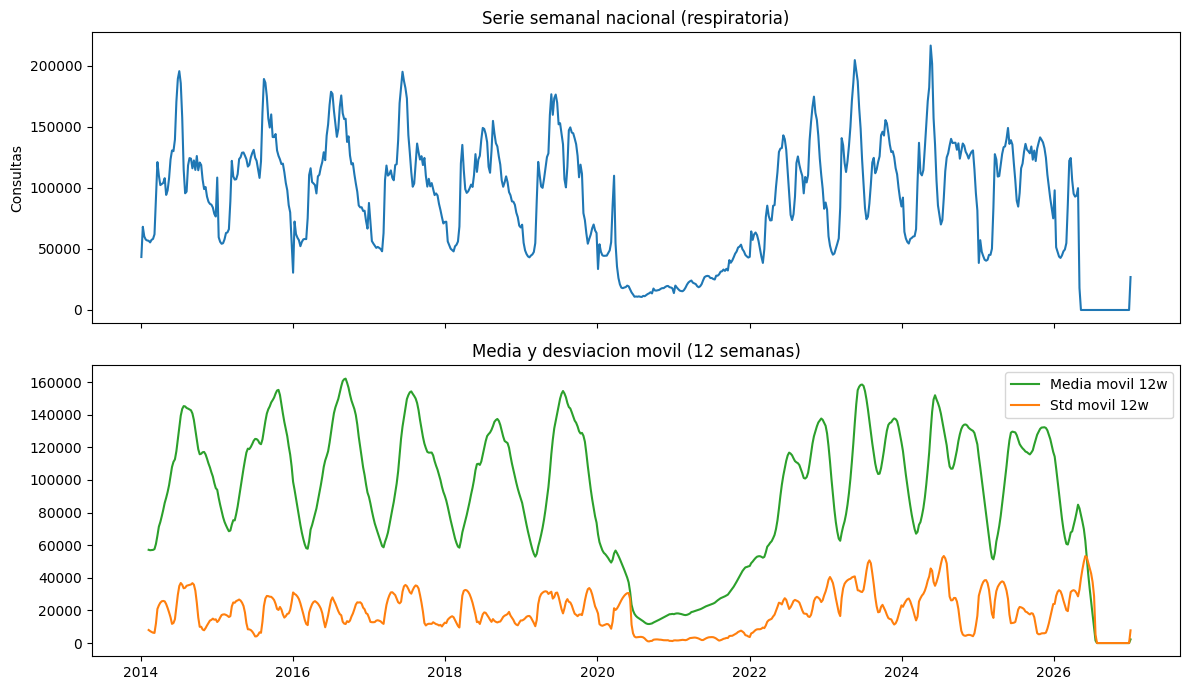

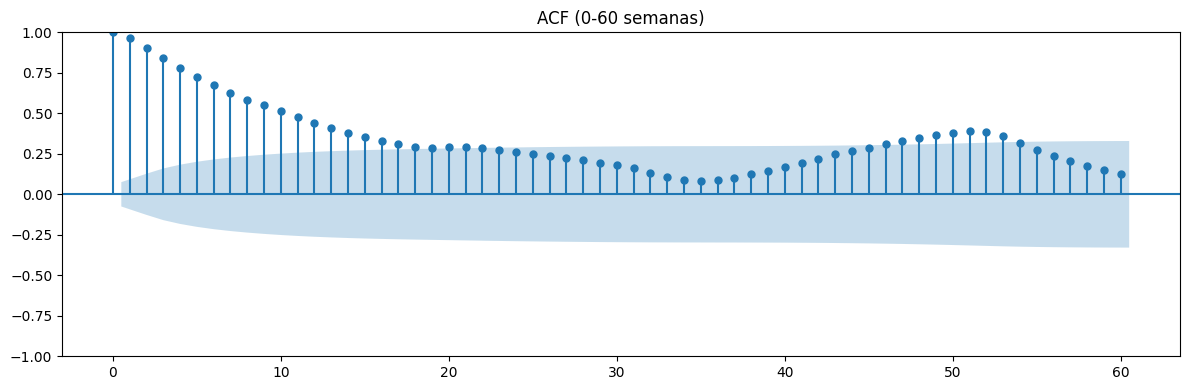

In [13]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = series.sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(series.index, series.values, color="tab:blue")
axes[0].set_title("Serie semanal nacional (respiratoria)")
axes[0].set_ylabel("Consultas")

roll_mean = series.rolling(12, min_periods=6).mean()
roll_std = series.rolling(12, min_periods=6).std()
axes[1].plot(series.index, roll_mean, color="tab:green", label="Media movil 12w")
axes[1].plot(series.index, roll_std, color="tab:orange", label="Std movil 12w")
axes[1].legend()
axes[1].set_title("Media y desviacion movil (12 semanas)")
plt.tight_layout()
plt.show()

# ACF on its own axis to avoid compression
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(series.dropna(), lags=60, ax=ax)
ax.set_title("ACF (0-60 semanas)")
plt.tight_layout()
plt.show()

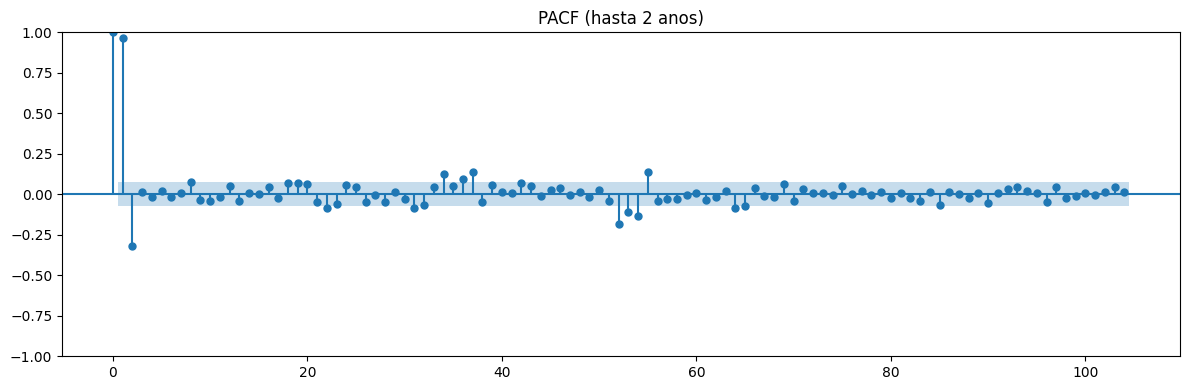

In [14]:
# PACF to see partial autocorrelation
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(series.dropna(), lags=104, ax=ax, method="ywm")
ax.set_title("PACF (hasta 2 anos)")
plt.tight_layout()
plt.show()

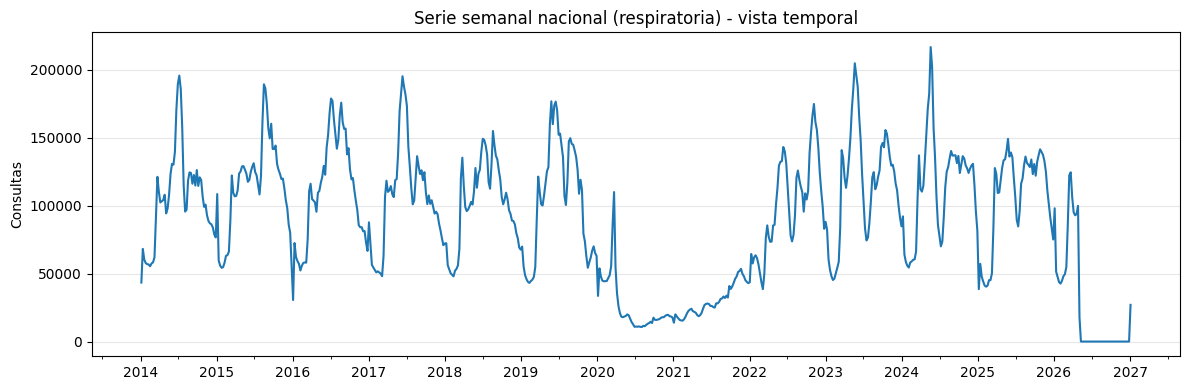

In [15]:
# Simple time-series view with yearly markers
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series.values, color="tab:blue")
ax.set_title("Serie semanal nacional (respiratoria) - vista temporal")
ax.set_ylabel("Consultas")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

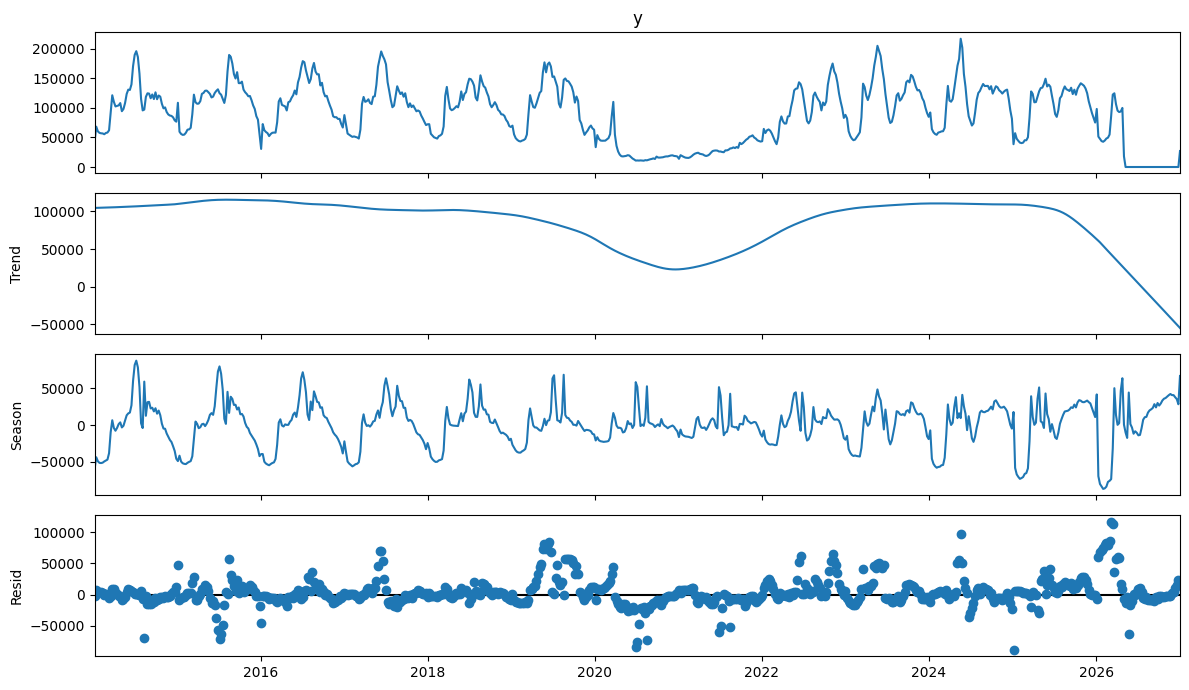

In [16]:
from statsmodels.tsa.seasonal import STL

# Decompose into trend/seasonal/residual (weekly seasonality ~ 52)
stl = STL(series, period=52, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(12, 7)
plt.tight_layout()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(x, label):
    x = x.dropna()
    adf_res = adfuller(x, autolag="AIC")
    kpss_res = kpss(x, regression="c", nlags="auto")
    return {
        "serie": label,
        "adf_stat": float(adf_res[0]),
        "adf_pvalue": float(adf_res[1]),
        "kpss_stat": float(kpss_res[0]),
        "kpss_pvalue": float(kpss_res[1]),
    }

tests = []
tests.append(stationarity_tests(series, "nivel"))

diff_1 = series.diff()
tests.append(stationarity_tests(diff_1, "d=1"))

diff_seasonal = series.diff(52)
tests.append(stationarity_tests(diff_seasonal, "D=1 (52w)"))

diff_both = series.diff(52).diff()
tests.append(stationarity_tests(diff_both, "d=1, D=1 (52w)"))

tests

C:\Users\Camilo\AppData\Local\Temp\ipykernel_17380\3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
C:\Users\Camilo\AppData\Local\Temp\ipykernel_17380\3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
C:\Users\Camilo\AppData\Local\Temp\ipykernel_17380\3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")


[{'serie': 'nivel',
  'adf_stat': -4.793026666332506,
  'adf_pvalue': 5.608129971457649e-05,
  'kpss_stat': 0.40453945574584854,
  'kpss_pvalue': 0.07519851045437563},
 {'serie': 'd=1',
  'adf_stat': -7.109996268944584,
  'adf_pvalue': 3.961805765620778e-10,
  'kpss_stat': 0.03239568545528029,
  'kpss_pvalue': 0.1},
 {'serie': 'D=1 (52w)',
  'adf_stat': -3.7554928238768555,
  'adf_pvalue': 0.0033969554508307886,
  'kpss_stat': 0.26402883747791894,
  'kpss_pvalue': 0.1},
 {'serie': 'd=1, D=1 (52w)',
  'adf_stat': -9.665075728712115,
  'adf_pvalue': 1.3218651189823912e-16,
  'kpss_stat': 0.022421644712885345,
  'kpss_pvalue': 0.1}]

In [ ]:
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Small SARIMA grid search (kept compact to avoid long runtimes)
p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1]
P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]
s = 52

results = []
for p, d, q, P, D, Q in product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals):
    order = (p, d, q)
    seasonal_order = (P, D, Q, s)
    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic,
        })
    except Exception:
        continue

import pandas as pd
grid = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
grid.head(10)

KeyboardInterrupt: 

: 